# Diffusion Inference Acceleration

I explore several ways to reduce diffusion inference cost without retraining a full model from scratch.  
The experiments cover activation caching inside a diffusion U-Net, reduced numerical precision, optimized attention, model distillation, and alternative sampling schedulers.

I keep the comparisons intentionally small and visual: the goal is to measure practical speedups while checking that the generated samples remain reasonable.

> Environment used while preparing this notebook: `diffusers==0.35.2`, `transformers==4.46.3`, `huggingface_hub==0.36.0`.


## 1. Activation Caching

Adjacent diffusion timesteps often produce similar intermediate U-Net features. I test whether reusing deeper activations across several denoising steps can reduce inference time without noticeably degrading the final sample.

I vary two parameters:

- `caching_level` — how much of the U-Net is skipped when cached features are reused;
- `cache_every` — how often I recompute the full U-Net and refresh the cache.


In [ ]:
# OpenAI guided-diffusion repository and the pretrained ImageNet 128x128 checkpoint
!git clone https://github.com/openai/guided-diffusion.git
!wget https://openaipublic.blob.core.windows.net/diffusion/jul-2021/128x128_diffusion.pt


In [1]:
import sys
import time
import torch
import requests
import numpy as np
import matplotlib.pyplot as plt
from diffusers import StableDiffusionPipeline

sys.path.append("guided-diffusion")

from PIL import Image
from tqdm import tqdm
from io import BytesIO
from guided_diffusion.unet import UNetModel
from guided_diffusion.nn import timestep_embedding

device = "cuda"


/home/jovyan/.local/lib/python3.12/site-packages/transformers/loss/loss_for_object_detection.py:28: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.5.2)
  from scipy.optimize import linear_sum_assignment


In [2]:
# Original 1000-step diffusion schedule used for the ImageNet experiment
T = 1000
betas = np.linspace(1e-4, 0.02, T)
alphas = np.cumprod(1 - betas, axis=0)


### Cached U-Net forward pass

`UnetCacheWrapper` keeps the original U-Net weights unchanged. On cache refresh steps I run the full network and store a deep activation. On the intermediate steps I reuse that activation and skip the corresponding expensive part of the network.


In [3]:
class UnetCacheWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x, t, y=None, cache=None, cache_i=-1):
        emb = self.model.time_embed(timestep_embedding(t, self.model.model_channels))

        if self.model.num_classes is not None:
            assert y.shape == (x.shape[0],)
            emb = emb + self.model.label_emb(y)

        # Encoder
        h = x.type(self.model.dtype)
        hs = []
        for i, module in enumerate(self.model.input_blocks):
            if cache is not None and cache_i == i:
                break
            h = module(h, emb)
            hs.append(h)

        # Middle block
        if cache is None:
            h = self.model.middle_block(h, emb)
        else:
            h = cache

        # Decoder
        for i, module in enumerate(self.model.output_blocks):
            if cache is not None and len(self.model.output_blocks) - i > cache_i:
                continue
            elif cache is None and len(self.model.output_blocks) - i == cache_i:
                cache = h

            h = torch.cat([h, hs.pop()], dim=1)
            h = module(h, emb)

        return self.model.out(h.type(x.dtype)), cache


In [4]:
model128 = UNetModel(
    image_size=128,
    in_channels=3,
    out_channels=6,
    model_channels=256,
    channel_mult=(1, 1, 2, 3, 4),
    num_res_blocks=2,
    num_heads=4,
    attention_resolutions=(16, 8, 4),
    num_classes=1000,
    resblock_updown=True,
    use_scale_shift_norm=True,
)

model128.to(device)
model128.load_state_dict(torch.load("128x128_diffusion.pt"))
model128_cache = UnetCacheWrapper(model128)


/tmp/ipykernel_1818/3733427608.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model128.load_state_dict(torch.load("128x128_diffusion.pt"))


### Cache depth / refresh-frequency sweep

I use the same random seed for every configuration so that differences in the samples come from caching rather than from a different noise trajectory. `(-1, 1)` is the uncached baseline.


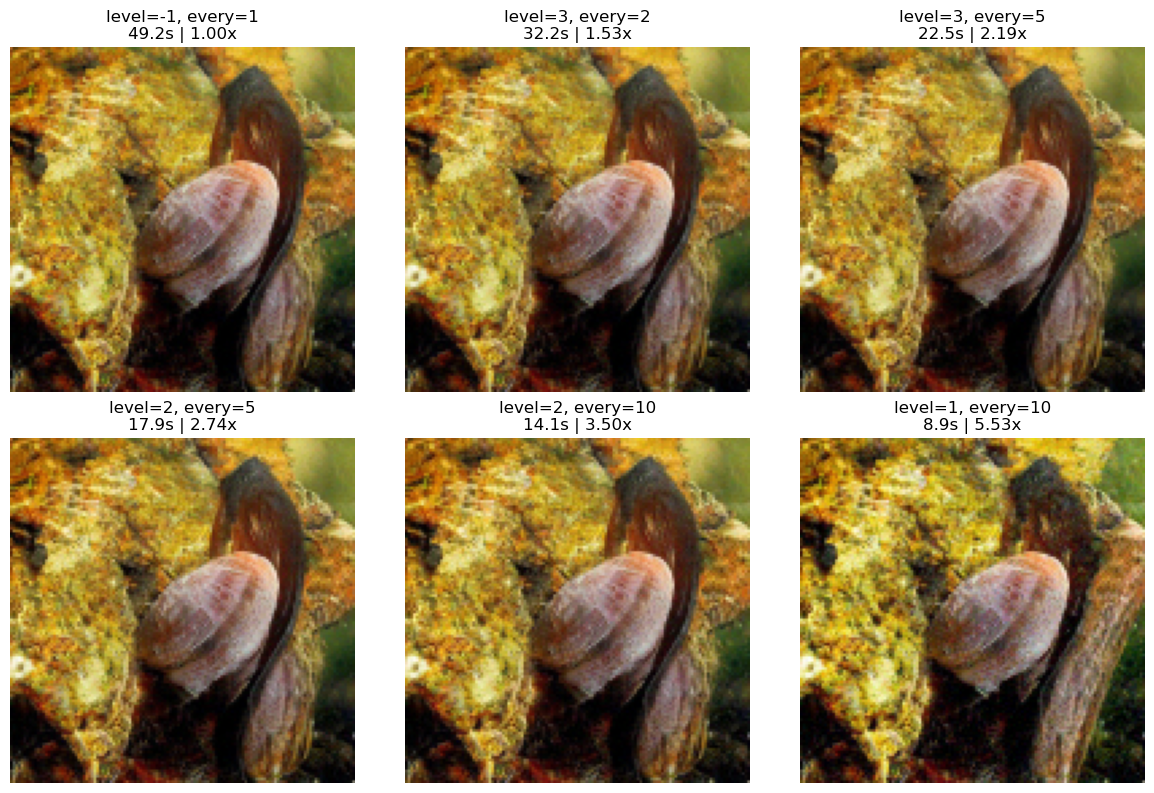

In [5]:
seed = 42
class_id = 113

configs = [
    (-1, 1),
    (3, 2),
    (3, 5),
    (2, 5),
    (2, 10),
    (1, 10),
]

cache_results = []
cache_images = []

for caching_level, cache_every in configs:
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    x_t = torch.randn((1, 3, 128, 128), device=device, dtype=torch.float32)
    y = torch.tensor([class_id], device=device, dtype=torch.int32)
    cache = None

    torch.cuda.synchronize()
    start = time.perf_counter()

    for t in tqdm(reversed(range(T)), total=T, leave=False):
        t_ = torch.tensor([t], device=device, dtype=torch.int32)

        with torch.no_grad():
            if t % cache_every == 0 or t == T - 1:
                eps_prediction, cache = model128_cache(x_t, t_, y, cache=None, cache_i=caching_level)
            else:
                eps_prediction, _ = model128_cache(x_t, t_, y, cache=cache, cache_i=caching_level)

            eps_prediction = eps_prediction[:, :3]

            x_t = (
                (x_t - betas[t] / np.sqrt(1 - alphas[t]) * eps_prediction)
                / np.sqrt(1 - betas[t])
                + np.sqrt(betas[t]) * torch.randn_like(x_t)
            )

    torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    image = ((x_t[0].permute(1, 2, 0).cpu().clamp(-1, 1) * 127.5 + 127.5).numpy().astype(np.uint8))

    cache_results.append((caching_level, cache_every, elapsed))
    cache_images.append(image)

baseline_time = cache_results[0][2]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, image, (level, every, elapsed) in zip(axes.flat, cache_images, cache_results):
    ax.imshow(image)
    ax.set_title(
        f"level={level}, every={every}\n"
        f"{elapsed:.1f}s | {baseline_time / elapsed:.2f}x"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()


With `caching_level=2` and `cache_every=10`, I get a 3.5× speedup while the generated sample remains visually very close to the baseline.

More aggressive caching (`caching_level=1`, `cache_every=10`) reaches 5.53×, but changes in fine texture and image structure become more noticeable.

## 2. Stable Diffusion Inference Optimizations

I use Stable Diffusion v1.4 as a common baseline and compare several independent inference optimizations. The prompt, number of denoising steps, and random seed stay fixed so that the visual comparison remains meaningful.

The timings below measure generation only; model loading is excluded.


In [13]:
prompt = "cheetah"
seed = 42
num_inference_steps = 30

sd_timings = {}


### 2.1 FP32 baseline

I first run Stable Diffusion v1.4 in full precision and explicitly use the non-SDPA attention processor. This serves as the reference configuration.


Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

4.80 s


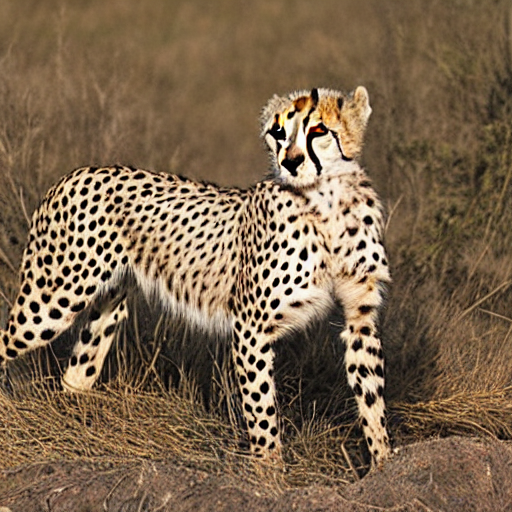

In [14]:
pipe = StableDiffusionPipeline.from_pretrained("CompVis/stable-diffusion-v1-4").to(device)

# Disable the PyTorch 2.x SDPA processor for the baseline.
pipe.unet.set_default_attn_processor()
pipe.vae.set_default_attn_processor()

generator = torch.Generator(device=device).manual_seed(seed)

torch.cuda.synchronize()
start = time.perf_counter()
image_fp32 = pipe(prompt, num_inference_steps=num_inference_steps, generator=generator,).images[0]
torch.cuda.synchronize()

sd_timings["SD v1.4 FP32"] = time.perf_counter() - start
print(f'{sd_timings["SD v1.4 FP32"]:.2f} s')
image_fp32


### 2.2 Reduced precision

I keep the same model and sampling settings, but switch the pipeline to `bfloat16`.


Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

10.21 s


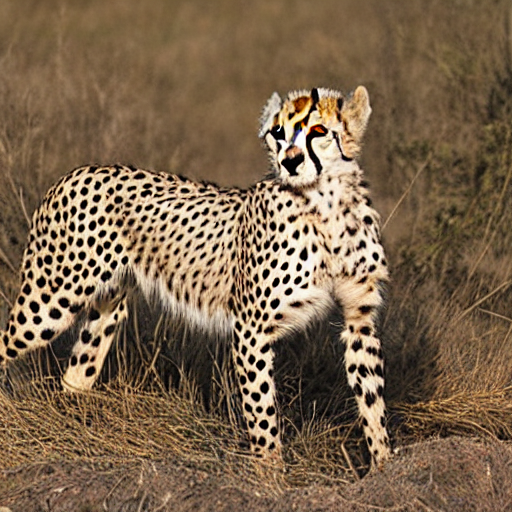

In [15]:
pipe = StableDiffusionPipeline.from_pretrained(
    "CompVis/stable-diffusion-v1-4", torch_dtype=torch.bfloat16,).to(device)

pipe.unet.set_default_attn_processor()
pipe.vae.set_default_attn_processor()

generator = torch.Generator(device=device).manual_seed(seed)

torch.cuda.synchronize()
start = time.perf_counter()
image_bf16 = pipe(prompt, num_inference_steps=num_inference_steps, generator=generator,).images[0]
torch.cuda.synchronize()

sd_timings["SD v1.4 BF16"] = time.perf_counter() - start
print(f'{sd_timings["SD v1.4 BF16"]:.2f} s')
image_bf16


### 2.3 Scaled dot-product attention

Next I keep `bfloat16` but allow the pipeline to use its optimized PyTorch 2.x attention implementation.


Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

11.45 s


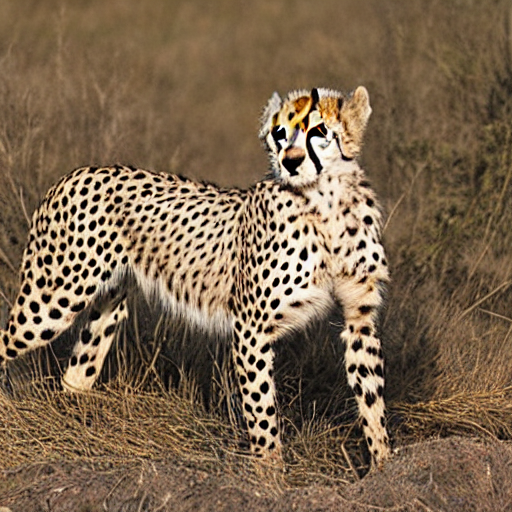

In [16]:
pipe = StableDiffusionPipeline.from_pretrained(
    "CompVis/stable-diffusion-v1-4", torch_dtype=torch.bfloat16,).to(device)

generator = torch.Generator(device=device).manual_seed(seed)

torch.cuda.synchronize()
start = time.perf_counter()
image_sdpa = pipe(prompt, num_inference_steps=num_inference_steps, generator=generator,).images[0]
torch.cuda.synchronize()

sd_timings["SD v1.4 BF16 + SDPA"] = time.perf_counter() - start
print(f'{sd_timings["SD v1.4 BF16 + SDPA"]:.2f} s')
image_sdpa


### 2.4 Distilled U-Net: BK-SDM

BK-SDM-small removes part of the original Stable Diffusion U-Net and distills the reduced architecture. I compare it with the same prompt, seed, and number of denoising steps.


Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

1.14 s


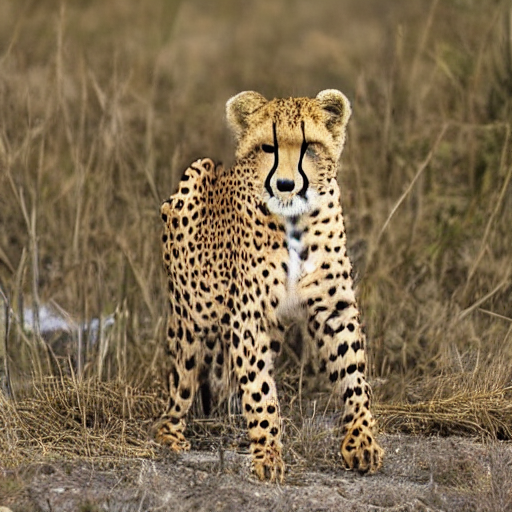

In [17]:
pipe = StableDiffusionPipeline.from_pretrained(
    "nota-ai/bk-sdm-small", torch_dtype=torch.float16, use_safetensors=True,).to(device)

generator = torch.Generator(device=device).manual_seed(seed)

torch.cuda.synchronize()
start = time.perf_counter()
image_bksdm = pipe(prompt, num_inference_steps=num_inference_steps, generator=generator,).images[0]
torch.cuda.synchronize()

sd_timings["BK-SDM-small FP16"] = time.perf_counter() - start
print(f'{sd_timings["BK-SDM-small FP16"]:.2f} s')
image_bksdm


### Visual and latency comparison

The image grid makes the quality differences visible, while the timing summary shows the inference speedup relative to the FP32 baseline.


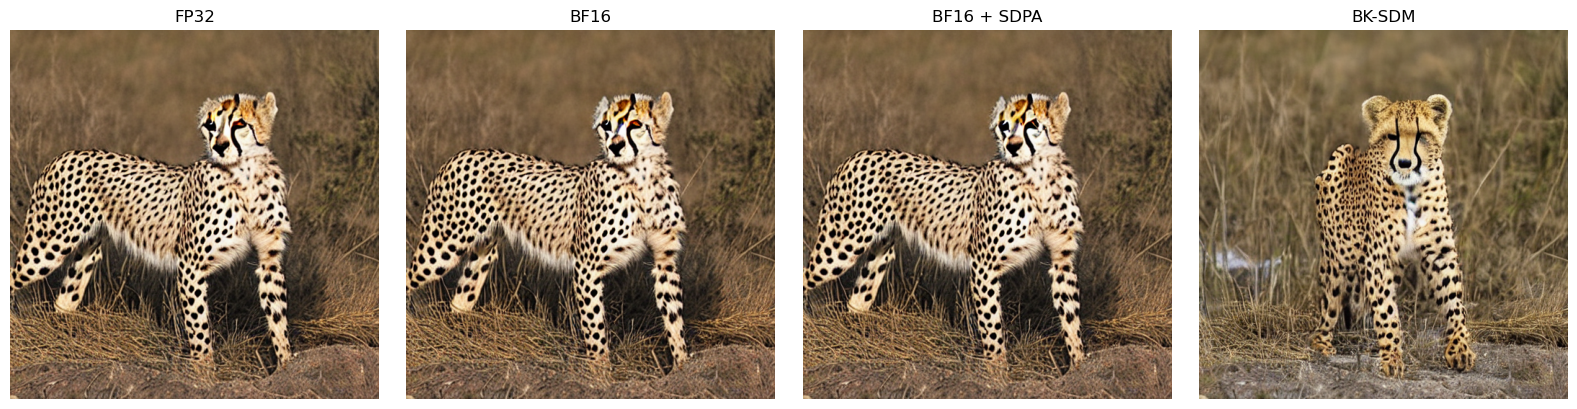

SD v1.4 FP32               4.80 s    1.00x
SD v1.4 BF16              10.21 s    0.47x
SD v1.4 BF16 + SDPA       11.45 s    0.42x
BK-SDM-small FP16          1.14 s    4.22x


In [18]:
images = [
    ("FP32", image_fp32),
    ("BF16", image_bf16),
    ("BF16 + SDPA", image_sdpa),
    ("BK-SDM", image_bksdm),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (title, image) in zip(axes, images):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

baseline = sd_timings["SD v1.4 FP32"]
for name, elapsed in sd_timings.items():
    print(f"{name:<24} {elapsed:6.2f} s   {baseline / elapsed:5.2f}x")


## 3. Scheduler Comparison

Finally, I keep the distilled model fixed and change only the sampler. I compare three compatible schedulers with the same seed and the same number of inference steps.

This isolates the effect of the numerical sampling strategy from changes in model weights or precision.


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

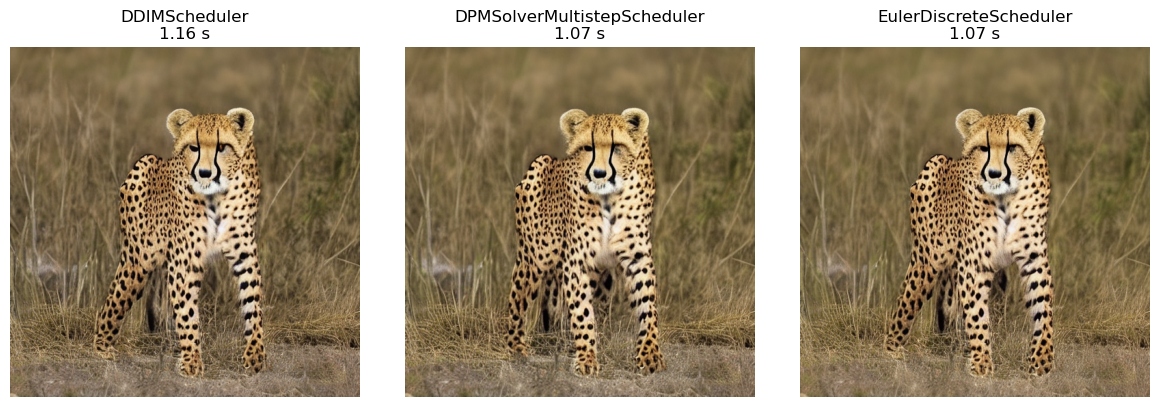

In [19]:
from diffusers import (
    DDIMScheduler,
    DPMSolverMultistepScheduler,
    EulerDiscreteScheduler,
)

base_scheduler_config = pipe.scheduler.config

scheduler_classes = [
    DDIMScheduler,
    DPMSolverMultistepScheduler,
    EulerDiscreteScheduler,
]

scheduler_images = []
scheduler_timings = []

for scheduler_cls in scheduler_classes:
    pipe.scheduler = scheduler_cls.from_config(base_scheduler_config)
    generator = torch.Generator(device=device).manual_seed(seed)

    torch.cuda.synchronize()
    start = time.perf_counter()
    image = pipe(
        prompt,
        num_inference_steps=num_inference_steps,
        generator=generator,
    ).images[0]
    torch.cuda.synchronize()

    elapsed = time.perf_counter() - start
    scheduler_images.append(image)
    scheduler_timings.append(elapsed)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, scheduler_cls, image, elapsed in zip(axes, scheduler_classes, scheduler_images, scheduler_timings):
    ax.imshow(image)
    ax.set_title(f"{scheduler_cls.__name__}\n{elapsed:.2f} s")
    ax.axis("off")

plt.tight_layout()
plt.show()


## 4. Summary

I use the visual grids above as the main result: they show where inference becomes faster without an obvious collapse in sample quality. The timing values provide the corresponding speedup for each configuration.
